# **1. Load Dataset**

In [ ]:
!pip -q install roboflow torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.0 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torchvision
import numpy as np
from PIL import Image

from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
import torchvision.transforms as T

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="FubcSJVDHEnV0FhKPMWy")
project = rf.workspace("nguyns-workspace-th4ak").project("dengue-fever-detection")
version = project.version(2)

dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dengue-fever-detection-2 in coco:: 100%|██████████| 9703/9703 [00:01<00:00, 5145.72it/s]


In [ ]:
from torchvision.datasets import CocoDetection
import torch
import os
from PIL import Image

class RoboflowDetection(CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):

        super().__init__(img_folder, ann_file, transforms=None)
        self.custom_transforms = transforms

    def __getitem__(self, idx):

        img, target_coco = super().__getitem__(idx)

        boxes = []
        labels = []

        for obj in target_coco:
            x, y, w, h = obj['bbox']

            boxes.append([x, y, x + w, y + h])

            labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)


        coco_img_id = self.ids[idx]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([coco_img_id])         }


        if self.custom_transforms:
            img = self.custom_transforms(img)

        return img, target

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
import torchvision.transforms as T

transforms = T.Compose([
    T.ToTensor()
])

In [ ]:
import os
from torch.utils.data import DataLoader

#TRAIN

train_dataset = RoboflowDetection(
    img_folder=os.path.join(dataset.location, "train"),
    ann_file=os.path.join(dataset.location, "train/_annotations.coco.json"),
    transforms=transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers = 1,
    collate_fn=collate_fn
)

#VALID
valid_dataset = RoboflowDetection(
    img_folder=os.path.join(dataset.location, "valid"),
    ann_file=os.path.join(
        dataset.location,
        "valid/_annotations.coco.json"
    ),
    transforms=transforms
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

#TEST

test_dataset = RoboflowDetection(
    img_folder=os.path.join(dataset.location, "test"),
    ann_file=os.path.join(
        dataset.location,
        "test/_annotations.coco.json"
    ),
    transforms=transforms
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


# **2. Visualize images**

In [ ]:
images, targets = next(iter(train_loader))

print(images[0].shape)
print(targets[0])

torch.Size([3, 512, 512])
{'boxes': tensor([[  0.0000, 111.0000, 200.7110, 356.6300],
        [229.0000, 162.0000, 503.9560, 485.6670],
        [204.0000,  24.0000, 389.4670, 198.5930]]), 'labels': tensor([1, 1, 1]), 'image_id': tensor([1347])}


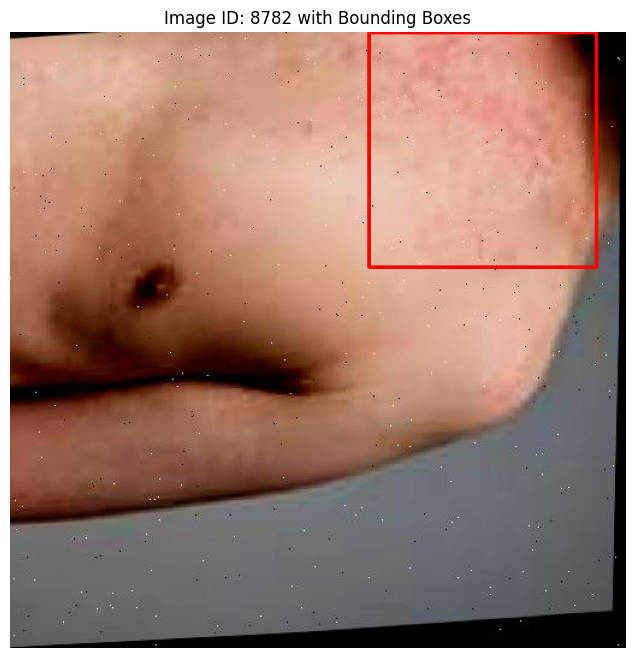

In [ ]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


images, targets = next(iter(train_loader))


image_tensor = images[2]
target_data = targets[2]


img_np = image_tensor.permute(1, 2, 0).cpu().numpy()


img_to_draw = (img_np * 255).astype(np.uint8)


boxes = target_data['boxes'].cpu().numpy()


img_with_bbox = img_to_draw.copy()


if len(boxes) > 0:
    for bbox in boxes:
        x1, y1, x2, y2 = bbox.astype(int)

        img_with_bbox = cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(img_with_bbox)
plt.title(f"Image ID: {target_data['image_id'].item()} with Bounding Boxes")
plt.axis('off')
plt.show()

In [ ]:
print(train_dataset.coco.dataset['categories'])

[{'id': 0, 'name': 'objects', 'supercategory': 'none'}, {'id': 1, 'name': 'dengue-rash', 'supercategory': 'objects'}]


# **3. Build Architecture**

In [ ]:
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 170MB/s]


In [ ]:
num_classes = 2

print("Classes:")
print(train_dataset.coco.dataset["categories"])

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

Classes:
[{'id': 0, 'name': 'objects', 'supercategory': 'none'}, {'id': 1, 'name': 'dengue-rash', 'supercategory': 'objects'}]


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()

    epoch_loss = 0

    for images, targets in loader:

        images = [
            img.to(device)
            for img in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in t.items()
            }
            for t in targets
        ]

        loss_dict = model(
            images,
            targets
        )

        losses = sum(
            loss
            for loss in loss_dict.values()
        )

        optimizer.zero_grad()

        losses.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        epoch_loss += losses.item()

    avg_loss = (epoch_loss/ len(loader)
    )

    return avg_loss

In [ ]:
from torchvision.ops import box_iou
import numpy as np

def evaluate_model(
    model,
    loader,
    iou_threshold=0.5
):

    model.eval()

    all_ious = []

    TP = 0
    FP = 0
    FN = 0

    with torch.no_grad():

        for images, targets in loader:

            images = [
                img.to(device)
                for img in images
            ]

            outputs = model(images)

            for pred, gt in zip(
                outputs,
                targets
            ):

                pred_boxes = pred["boxes"].cpu()
                pred_scores = pred["scores"].cpu()
                pred_labels = pred["labels"].cpu()
                keep = (
                    (pred_scores > 0.3)
                    &
                    (pred_labels == 1)
                )

                pred_boxes = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                pred_labels = pred_labels[keep]
                gt_boxes = gt["boxes"]

                if len(gt_boxes) == 0:

                    FP += len(pred_boxes)
                    continue

                if len(pred_boxes) == 0:

                    FN += len(gt_boxes)
                    continue

                ious = box_iou(
                    pred_boxes,
                    gt_boxes
                )

                max_iou_per_gt = (
                    ious.max(dim=0)[0]
                )

                all_ious.extend(
                    max_iou_per_gt.tolist()
                )

                tp_image = (
                    max_iou_per_gt
                    >= iou_threshold
                ).sum().item()

                fn_image = (
                    max_iou_per_gt
                    < iou_threshold
                ).sum().item()

                fp_image = max(
                    0,
                    len(pred_boxes)
                    - tp_image
                )

                TP += tp_image
                FP += fp_image
                FN += fn_image

    mean_iou = (
        np.mean(all_ious)
        if len(all_ious) > 0
        else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    print(
        f"Mean IoU : {mean_iou:.4f}"
    )
    print(
        f"Recall   : {recall:.4f}"
    )

    return (
        mean_iou,
        recall
    )

In [ ]:
def compute_val_loss(
    model,
    loader
):

    model.train()

    total_loss = 0

    with torch.no_grad():

        for images, targets in loader:

            images = [
                img.to(device)
                for img in images
            ]

            targets = [
                {
                    k: v.to(device)
                    for k, v in t.items()
                }
                for t in targets
            ]

            loss_dict = model(
                images,
                targets
            )

            losses = sum(
                loss
                for loss in loss_dict.values()
            )

            total_loss += losses.item()

    return total_loss / len(loader)

# **4. Training**

In [18]:
best_iou = float('-inf')

patience = 3

counter = 0

for epoch in range(10):

    avg_loss = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    val_loss = compute_val_loss(
        model,
        valid_loader
    )

    print(f"\nEpoch {epoch+1}")

    print(
        f"Train Loss: {avg_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    mean_iou, recall = (
        evaluate_model(
            model,
            valid_loader
        )
    )

    if mean_iou > best_iou:

        best_iou = mean_iou

        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print(
            "Best model saved"
        )

    else:

        counter += 1

        print(
            f"No improvement ({counter}/{patience})"
        )

    if counter >= patience:

        print(
            "Early stopping triggered"
        )

        break


Epoch 1
Train Loss: 0.2460
Val Loss: 0.0808
Mean IoU : 0.5342
Recall   : 0.5476
Best model saved

Epoch 2
Train Loss: 0.1366
Val Loss: 0.0754
Mean IoU : 0.5230
Recall   : 0.4881
No improvement (1/3)

Epoch 3
Train Loss: 0.1285
Val Loss: 0.0731
Mean IoU : 0.5172
Recall   : 0.5119
No improvement (2/3)

Epoch 4
Train Loss: 0.1240
Val Loss: 0.0758
Mean IoU : 0.5760
Recall   : 0.6548
Best model saved

Epoch 5
Train Loss: 0.1171
Val Loss: 0.0795
Mean IoU : 0.6062
Recall   : 0.6786
Best model saved

Epoch 6
Train Loss: 0.1137
Val Loss: 0.0705
Mean IoU : 0.5566
Recall   : 0.6310
No improvement (1/3)

Epoch 7
Train Loss: 0.1120
Val Loss: 0.0823
Mean IoU : 0.5854
Recall   : 0.6429
No improvement (2/3)

Epoch 8
Train Loss: 0.1132
Val Loss: 0.0715
Mean IoU : 0.5680
Recall   : 0.6310
No improvement (3/3)
Early stopping triggered


In [24]:
import os

print(os.path.exists("best_model.pth"))

True


# **5. Evaluation**

In [19]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.2 MB/s eta 0:00:00


In [20]:
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

model.to(device)

print(
    "\n=== TEST SET ==="
)

test_iou, test_recall = (
    evaluate_model(
        model,
        test_loader
    )
)


=== TEST SET ===

=== TEST SET ===
Mean IoU : 0.5873
Recall   : 0.6803
Mean IoU : 0.5873
Recall   : 0.6803


In [21]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def evaluate_map(
    model,
    loader
):

    metric = MeanAveragePrecision()

    model.eval()

    with torch.no_grad():

        for images, targets in loader:

            images = [
                img.to(device)
                for img in images
            ]

            outputs = model(images)

            preds = []

            gts = []

            for pred, gt in zip(
                outputs,
                targets
            ):

                preds.append({
                    "boxes":
                        pred["boxes"].cpu(),
                    "scores":
                        pred["scores"].cpu(),
                    "labels":
                        pred["labels"].cpu()
                })

                gts.append({
                    "boxes":
                        gt["boxes"].cpu(),
                    "labels":
                        gt["labels"].cpu()
                })

            metric.update(
                preds,
                gts
            )

    result = metric.compute()

    print(
        "mAP50:",
        result["map_50"].item()
    )

    print(
        "mAP75:",
        result["map_75"].item()
    )

    return result

evaluate_map(
    model,
    test_loader
)

mAP50: 0.5282182097434998
mAP75: 0.15578420460224152
mAP50: 0.5282182097434998
mAP75: 0.15578420460224152


{'map': tensor(0.2259),
 'map_50': tensor(0.5282),
 'map_75': tensor(0.1558),
 'map_small': tensor(0.),
 'map_medium': tensor(0.0046),
 'map_large': tensor(0.2399),
 'mar_1': tensor(0.2469),
 'mar_10': tensor(0.3537),
 'mar_100': tensor(0.4000),
 'mar_small': tensor(0.),
 'mar_medium': tensor(0.1625),
 'mar_large': tensor(0.4167),
 'map_per_class': tensor(-1.),
 'mar_100_per_class': tensor(-1.),
 'classes': tensor(1, dtype=torch.int32)}

{'map': tensor(0.2259),
 'map_50': tensor(0.5282),
 'map_75': tensor(0.1558),
 'map_small': tensor(0.),
 'map_medium': tensor(0.0046),
 'map_large': tensor(0.2399),
 'mar_1': tensor(0.2469),
 'mar_10': tensor(0.3537),
 'mar_100': tensor(0.4000),
 'mar_small': tensor(0.),
 'mar_medium': tensor(0.1625),
 'mar_large': tensor(0.4167),
 'map_per_class': tensor(-1.),
 'mar_100_per_class': tensor(-1.),
 'classes': tensor(1, dtype=torch.int32)}

# **6. Error Analysis**

Top scores:
tensor([0.9939, 0.3454, 0.2599, 0.1961, 0.1098, 0.0943, 0.0697, 0.0543])
Total predicted boxes:
8


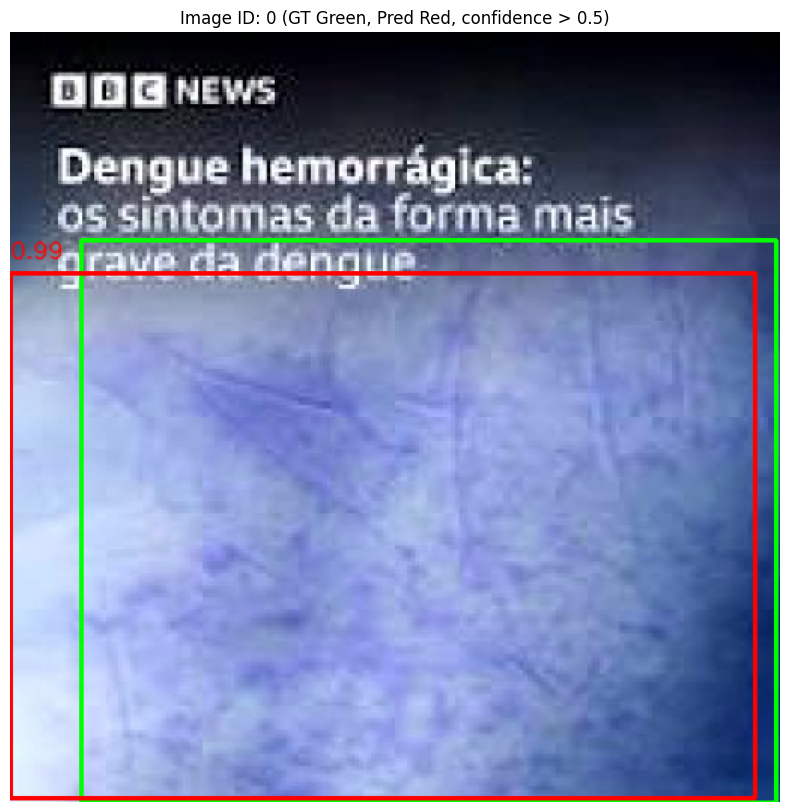

In [26]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.ops as ops

model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

model.to(device)
model.eval()


images, targets = next(iter(valid_loader))


image_tensor = images[0]
original_target_data = targets[0]


model.eval()
image_tensor_to_model = image_tensor.to(device)
with torch.no_grad():
    outputs_from_model = model([image_tensor_to_model])
predicted_data = outputs_from_model[0]


img_np = image_tensor.permute(1, 2, 0).cpu().numpy()
img_to_draw = (img_np * 255).astype(np.uint8)


predicted_boxes = predicted_data['boxes'].cpu().detach()
predicted_scores = predicted_data['scores'].cpu().detach()
print("Top scores:")
print(predicted_scores[:20])

print("Total predicted boxes:")
print(len(predicted_scores))


iou_threshold = 0.5
confidence_threshold = 0.5

keep = predicted_scores > confidence_threshold

predicted_boxes = predicted_boxes[keep]
predicted_scores = predicted_scores[keep]

if len(predicted_boxes) > 0:

    nms_indices = ops.nms(
        predicted_boxes,
        predicted_scores,
        0.5
    )

    filtered_predicted_boxes = predicted_boxes[nms_indices].numpy()
    filtered_predicted_scores = predicted_scores[nms_indices].numpy()

else:

    filtered_predicted_boxes = np.array([])
    filtered_predicted_scores = np.array([])

img_combined = img_to_draw.copy()


original_boxes = original_target_data['boxes'].cpu().numpy()
if len(original_boxes) > 0:
    for bbox in original_boxes:
        x1, y1, x2, y2 = bbox.astype(int)
        cv2.rectangle(img_combined, (x1, y1), (x2, y2), (0, 255, 0), 2)


if len(filtered_predicted_boxes) > 0:
    for bbox, score in zip(filtered_predicted_boxes, filtered_predicted_scores):
        x1, y1, x2, y2 = bbox.astype(int)
        cv2.rectangle(img_combined, (x1, y1), (x2, y2), (0, 0, 255), 2)

        text = f"{score:.2f}"
        text_x = x1
        text_y = y1 - 10 if y1 - 10 > 10 else y1 + 10
        cv2.putText(img_combined, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(10, 10))
plt.imshow(
    cv2.cvtColor(
        img_combined,
        cv2.COLOR_BGR2RGB
    )
)
plt.title(f"Image ID: {original_target_data['image_id'].item()} (GT Green, Pred Red, confidence > {confidence_threshold})")
plt.axis('off')
plt.show()

In [27]:
model.eval()

images, targets = next(iter(valid_loader))

image = images[0].to(device)

with torch.no_grad():
    outputs = model([image])

print(outputs)

print(
    outputs[0]["scores"][:20]
)

print(
    len(outputs[0]["boxes"])
)

[{'boxes': tensor([[  0.0000, 160.6849, 495.0023, 509.3456],
        [ 20.8246, 149.0347, 266.2654, 509.5251],
        [139.4483,  53.6674, 512.0000, 413.7487],
        [406.5403,   4.0614, 505.9417, 502.6311],
        [257.4601, 129.9813, 504.5570, 498.7628],
        [ 25.6764,  32.7003, 221.4924,  91.2157],
        [321.3938,  86.9834, 512.0000, 346.9966],
        [ 46.0783,  60.9177, 383.3371, 442.3548]], device='cuda:0'), 'labels': tensor([1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0'), 'scores': tensor([0.9939, 0.3454, 0.2599, 0.1961, 0.1098, 0.0943, 0.0697, 0.0543],
       device='cuda:0')}]
tensor([0.9939, 0.3454, 0.2599, 0.1961, 0.1098, 0.0943, 0.0697, 0.0543],
       device='cuda:0')
8
